# Week 5: Orthonormal frames and bases

This week you should make sure you learn:

1. The definition of an *orthonormal frame* and an *orthonormal basis*
1. The standard basis is an example of an orthonormal basis
1. Moving from one orthonormal basis to another doesn't distort angles or distances
1. If the columns of $H$ are one orthonormal frame of dimension $d$, and the columns of $C$ are another orthonrmal from of dimension $c$, then $H@C.T$ moves from the $C$-frame to the $H$-frame
1. If $h_0,\ldots,h_{d-1}$ is any collection of $nD$ vectors, let $H$ be the matrix with the $h$s as its columns. Then the $h$s are orhonormal precisley when $H^T@H$ is the $n\times n$ identity matrix.
1. If $h_0,\ldots,h_{d-1}$ is an orthonormal frame, and $H$ is the matrix with the $h$s as its columns, then the orthogonal projection of $v$ onto the span of the $h$s is given by 
$$
P_H(v) = (h_0 @ v) * h_0 + \ldots (h_{d-1}@v) * h_{d-1} = H@H.T @ v.
$$
7. If $b_0,...,b_{n-1}$ are $n$ $nD$ vectors, and if $B$ is the matrix with the $b$s as its colums, then $b_0,\ldots,b_{n-1}$ is an orthonormal basis precisely when $B^T @B$ is the $n\times n$ identify matrix.
8. If $b_0,\ldots,b_{n-1}$ is an orthonormal basis, and $B$ is the matrix with the $b$s as its columns, then 
$$
v = (b_0 @ v) * b_0 + \ldots (b_{n-1}@v) * b_{n-1}.
$$
That is, the $j$ coordinate of $v$ in the basis of $b$s is $b_j @ v$.

## Initialization Cells

In [3]:
# This initialization cell imports standard python packages

import numpy as np
import numpy.linalg as la

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

import math
import scipy

# PIL is short for Python Image Library, and contains methods for working with image files like jpeg and png files.
from PIL import Image

# We need a random number generator

rng = np.random.default_rng()

In [4]:
# This initialization cell is for material special to Linear Algebra for Data Science

# This function sets up a standard 2D plot for demonstrations involving 2D vectors as arrows.
# Some key features

#  -- You can specify more than one plot. If you call LADS2DSquare(n), you get n plots side-by-side
#     If you call LADS2DSquare(c,r) you get c columns and r rows. Don't do that, instead, use the arguemtns as described below.
#  -- each plot is square and the aspect ratio is set to 1,
#     for true geometry: for example, orthogonal vectors will appear to be perpendicular
#  -- gridlines at integer points
#  -- the origin in the center
#  -- the line x=0 and the line y = 0 are prominent
#
#  -- If you ask for only one plot, you'll get a single instance. In other cases you'll get a 1D array
#     or a 2D array of Axes instances.

# You can set the low and high values of the plot

# Returns two things: the matplotlib figure and axes instances


def LADS2DSquare(ncols=1, nrows=1, xlow=-2., xhigh=2.):
    LADS2Dfig = plt.figure(figsize=[ncols * 6., nrows * 6.])
    nplot = nrows * ncols

    if nplot == 1:
        LADS2Dax = LADS2Dfig.add_axes([0, 0, 1, 1])
        LADS2Dax.set_xlim(xlow, xhigh)
        LADS2Dax.set_ylim(xlow, xhigh)
        LADS2Dax.set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax.axhline(y=0, color='gray')
        LADS2Dax.axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax.set_xticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))
        LADS2Dax.set_yticks(np.arange(math.ceil(xlow), math.floor(xhigh) + 1))

        LADS2Dax.grid(True)

        return LADS2Dfig, LADS2Dax

# else if nplot>1...
    LADS2Dax = LADS2Dfig.subplots(nrows, ncols)
    if min(nrows, ncols) == 1:
        for i in range(nplot):
            LADS2Dax[i].set_xlim(xlow, xhigh)
            LADS2Dax[i].set_ylim(xlow, xhigh)
            LADS2Dax[i].set_aspect('equal')

            # Add x and y axes crossing at origin (0.0)
            LADS2Dax[i].axhline(y=0, color='gray')
            LADS2Dax[i].axvline(x=0, color='gray')

            # Set ticks to a reasonable number
            LADS2Dax[i].set_xticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].set_yticks(
                np.arange(math.ceil(xlow),
                          math.floor(xhigh) + 1))
            LADS2Dax[i].grid(True)
# end for

        return LADS2Dfig, LADS2Dax
# end "if nplot>1"

#else if nrows>1 and ncols > 1...

    for i, j in np.ndindex(nrows, ncols):
        LADS2Dax[i, j].set_xlim(xlow, xhigh)
        LADS2Dax[i, j].set_ylim(xlow, xhigh)
        LADS2Dax[i, j].set_aspect('equal')

        # Add x and y axes crossing at origin (0.0)
        LADS2Dax[i, j].axhline(y=0, color='gray')
        LADS2Dax[i, j].axvline(x=0, color='gray')

        # Set ticks to a reasonable number
        LADS2Dax[i, j].set_xticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].set_yticks(
            np.arange(math.ceil(xlow),
                      math.floor(xhigh) + 1))
        LADS2Dax[i, j].grid(True)

    return LADS2Dfig, LADS2Dax


# This method draws arrows on an matplotlib axes class.

# this is a generic method, designed to be added to the matplotlib Axes class
# The hsv color map is good for drawing circles of vectors (where the end of the list will be near the beginning). Other colormaps may be better
# for arbitrary lists. See https://matplotlib.org/stable/tutorials/colors/colormaps.html


def LADS2DDrawVectorList(self, VectorList, cmap=cm.hsv,columns=False):
    #norm.autoscale(0,len(VectorList))
    VList = VectorList
    if columns: 
        VList = VectorList.T
        
    zeroes = np.zeros(len(VList))
    self.quiver(zeroes,
                zeroes,
                VList[:, 0],
                VList[:, 1],
                color=cmap(np.linspace(0, 1, len(VList),endpoint=False)),
                angles='xy',
                scale_units='xy',
                scale=1)


# This command adds the method above to Axes
plt.Axes.LADS2DDrawVectorList = LADS2DDrawVectorList

# these methods draws a single arrow in 2D and 3D


def LADS2DDrawVector(self, Vector, col='g', TailAt=np.array([0., 0.])):
    self.quiver([TailAt[0]], [TailAt[1]], [Vector[0]], [Vector[1]],
                color=col,
                angles='xy',
                scale_units='xy',
                scale=1)


plt.Axes.LADS2DDrawVector = LADS2DDrawVector

def LADS3DDrawVector(self, Vector, col='g', TailAt=np.array([0., 0., 0.])):
    self.quiver([TailAt[0]], [TailAt[1]], [TailAt[2]],[Vector[0]], [Vector[1]], [Vector[2]],
                color=col)

plt.Axes.LADS3DDrawVector = LADS3DDrawVector

# Creates a 2D rotation matrix: rotates by the angle theta, specified in radians, counterclockwise


def RotationMatrix2D(theta):
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta), np.cos(theta)]])



# This produces the j element of the standard basis in dimension d

def LADSStdBasis(j,*,dim):
    if j<0 or j>=dim:
        print("This basis element is not defined")
        return
    e = np.zeros(dim)
    e[j] = 1
    return e
    

## End of Initialization Cells

## Recall that a basis gives a coordinate system, and finding coordinates is like solving systems of linear equations

A basis for $\mathbb{R}^n$ gives a way of labeling vectors in $\mathbb{R}^n$: if $b_0,...,b_{n-1}$ is a basis, and $v$ is any vector in $\mathbb{R}^n$, then there are scalars $x_0,...,x_{n-1}$ such that
$$
   v = x_0 b_0 + x_1 b_1 + ... + x_{n-1} b_{n-1}.
$$
The numbers $x_0,...,x_{n-1}$ are the "coordinates" of $v$ in the basis $b_0, ..., b_{n-1}$.

> #### Bases are an important tool for measuring and understanding vectors.

Given a set of vectors $b_0,...,b_{n-1}$, some common questions are:

1. Are they a basis?
2. If they are a basis, and if $v$ is any vector, what are the cooridnates of $v$ in the basis $b_0,...,b_{n-1}$? Put another way, what are the scalars $x_0,...,x_{n-1}$ so that $v = x_0 b_0 + ... + x_{n-1}b_{n-1}$?



In Week 2, you saw that finding the coordinates of a vector in a basis is generally like solving systems of linear equations. Here is an example.

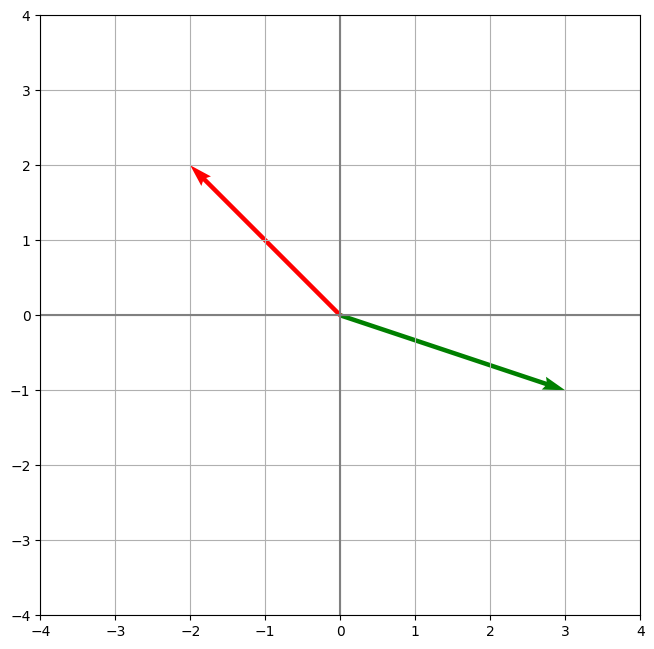

In [5]:
# Here is a basis 

fig,ax=LADS2DSquare(xlow=-4,xhigh=4)
b0 = np.array([3,-1])
b1 = np.array([-2,2])
ax.LADS2DDrawVector(b0)
ax.LADS2DDrawVector(b1,'red')

v= [1 0]


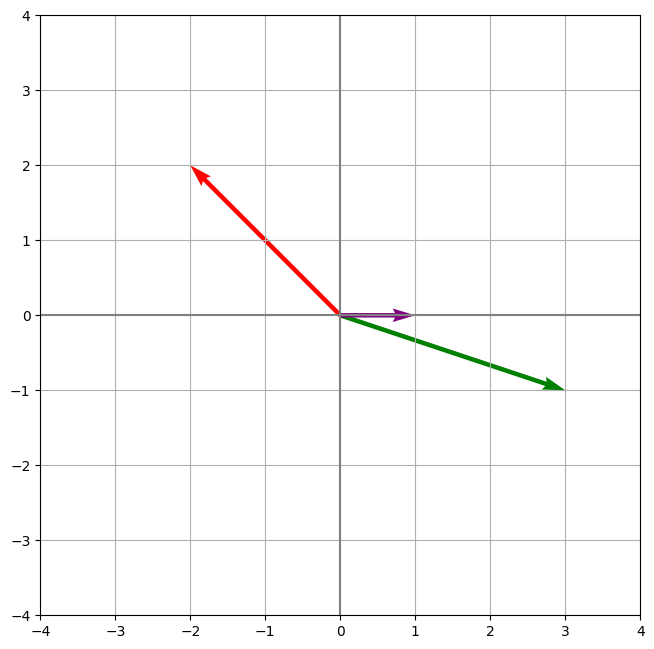

In [6]:
# Now here is a random vector in purple

v = rng.integers(low=-3,high=3,size=(2))

print("v=",v)
ax.LADS2DDrawVector(v,'purple')
fig


We can find the coordinates of $v$ in the basis $b0, b1$ using numpy's linear algebra solve method.

In [7]:
# First make a matrix with columns b0 and b1
M = np.array([b0,b1]).T
print("b0 = ",b0)
print("b1 = ",b1)
print("M =")
print(M)

# Then use la.solve

c0, c1 = la.solve(M,v)

print(f"c0 = {c0:0.3f}")
print(f"c1 = {c1:0.3f}")

# Check that v = c0 * b0 + c1 * b1

print("v=",v)
print("c0 b0 + c1 b1 = ", c0*b0 + c1*b1)

b0 =  [ 3 -1]
b1 =  [-2  2]
M =
[[ 3 -2]
 [-1  2]]
c0 = 0.500
c1 = 0.250
v= [1 0]
c0 b0 + c1 b1 =  [ 1.00000000e+00 -5.55111512e-17]


Let's see why this works. Let's remember the "column view" of applying a matrix to a vector. If $M$ is a 2 by 2 matrix with columns
$$
M = \begin{bmatrix} | & | \\
                    b0 & b1 \\
                    | & | 
    \end{bmatrix},
$$
and $c$ is a $2D$ vector with entries $c=[c0,c1]$, then 
$$
M@c = c0 * b0 + c1 * b1.
$$
So what la.solve is is doing is finding the vector $c$ so that $M@c = v.$ Let's check that.

v= [-3 -2]
b0 =  [ 3 -1]
b1 =  [-2  2]
M =
[[ 3 -2]
 [-1  2]]
c =  [-2.5  -2.25]
v =  [-3 -2]
M@c = [-3. -2.]


Text(0.5, 1.0, 'Here is M applied to the vector c found by la.xolve in yellow.')

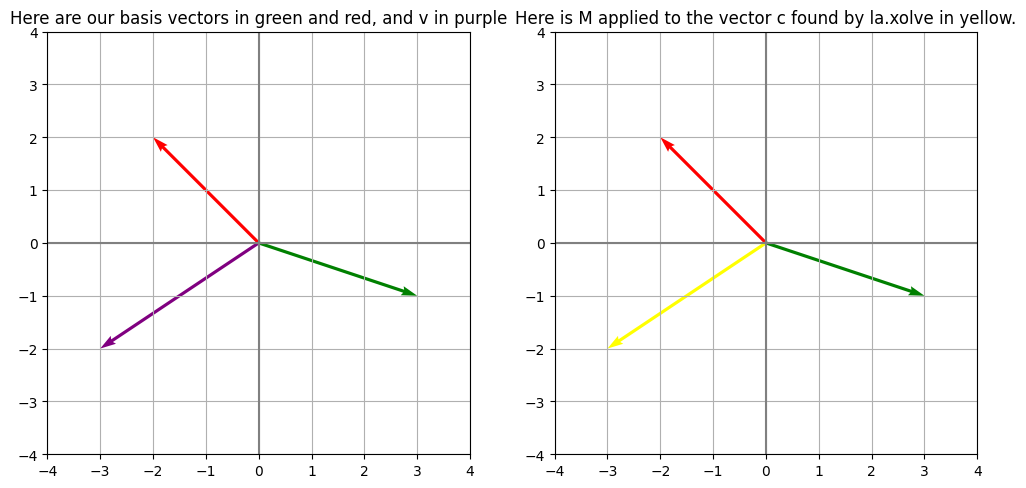

In [8]:
fig,ax=LADS2DSquare(ncols=2,xlow=-4,xhigh=4)

# Here are b0 and b1 again; we'll draw them on both axes.
b0 = np.array([3,-1])
b1 = np.array([-2,2])

ax[0].LADS2DDrawVector(b0)
ax[0].LADS2DDrawVector(b1,'red')
ax[1].LADS2DDrawVector(b0)
ax[1].LADS2DDrawVector(b1,'red')

# For purposes of exposition, we'll choose a 2D vector v instead of setting it randomly. 

v = np.array([-3,-2])
print("v=",v)
ax[0].LADS2DDrawVector(v,'purple')
ax[0].set_title("Here are our basis vectors in green and red, and v in purple")

# We make the matrix M with columns b0 and b1

M = np.array([b0,b1]).T
print("b0 = ",b0)
print("b1 = ",b1)
print("M =")
print(M)

# Now set c to be the vector that comes out of la.solve 

c = la.solve(M,v)
print("c = ",c)

#Finally check that M@c is equal to v, and draw it on the right axes.

print("v = ", v)
print("M@c =", M@c)
ax[1].LADS2DDrawVector(M@c,'yellow')
ax[1].set_title("Here is M applied to the vector c found by la.xolve in yellow.")


In Week 2, we saw why this routine is called "la.solve": it's solving systems of linear equations. Filling in the entries of $M$, $c$, and $v$ with their values, we see that solving $M@c = v$ is solving
$$ 
         \begin{bmatrix} 3 &  -2 \\ -1 & 2 \end{bmatrix}\begin{bmatrix} c0 \\ c1 \end{bmatrix} = \begin{bmatrix} -3 \\ -2 \end{bmatrix}
$$
for $c0$ and $c1$. This vector equation corresponds to two linear equations, 
$$
\begin{align*}
3 c0 - 2 c1 & = -3 \\
- c0 + 2 c1 & = -2.
\end{align*}
$$
So finding coordinates is solving systems of linear equations.

## Orthonormal frames and bases

>**Definitions:** A set of $n$ vectors $b_0,\ldots,b_{n-1}$ is **orthogonal** or an **orthogonal frame** if they are perpendicular to each other. A set of $n$ vectors $b_0,\ldots,b_{n-1}$ is **orthonormal** or an **orthonormal frame** if they are perpendicular to each other and each vector has length $1$.

>**Fact:** Any orthogonal set of vectors is linearly independent, and so it is a basis for its span.

> **Fact:** If $b_0,...,b_{n-1}$ is an orthonormal frame of $nD$ vectors, then they are an orthonormal basis for $\mathbb{R}^n$.

## Coordinates in an orthonormal frame

Orthonormal frames are important for two reasons, one visual and one computational. Visually, orthonormal frames look like the standard basis. Computationally, it is easy to find the coordiantes of vectors in an orthonormal frame.

This formula, and the one later in this lesson about orthogonal projection, are the most important formulas this week!

>**Fact:** If $b_0,\ldots,b_{n-1}$ is an orthonormal basis in dimension $n$, and $v$ is an $nD$ vector, then 
$$
v = (b_0 \cdot v) * b_0 + (b_1 \cdot v) * b_1 + \ldots + (b_{n-1} \cdot v)* b_{n-1}.
$$
>That is, the $j$ coordinate of $v$ in the basis $b_0,\ldots,b_{n-1}$ is $b_j \cdot v$.

Notice that you didn't have to solve a system of equations to find the coordinates of $v$: you just compute a few dot products. Let's see this at work.

### The standard basis


You already know one orthonormal basis. The "standard" basis in dimension $n$ is the $n$ vectors $e0,\ldots,e_{n-1}$ where $e_j$ is zero in every position except the $j$ position, where it is $1$. Here it is in 3D. Let's first check that is is an orthonormal basis. Notice that we are using a new function `LADSStdBasis` that creates standard basis vectors. It was defined in the initialization cell at the top of this notebook.

In [9]:
# We created a function to retun the vectors of the standard basis.

e0 = LADSStdBasis(0,dim=3)
e1 = LADSStdBasis(1,dim=3)
e2 = LADSStdBasis(2,dim=3)
print("e0 = ",e0)
print("e1 = ",e1)
print("e2 = ",e2)

# It's an orthonormal basis
print("The norm of e0 is ",la.norm(e0))
print("The norm of e1 is ",la.norm(e1))
print("The norm of e2 is ",la.norm(e2))

print("The dot product of e0 and e1 is ",e0@e1)
print("The dot product of e0 and e2 is ",e0@e2)
print("The dot product of e1 and e2 is ",e1@e2)



e0 =  [1. 0. 0.]
e1 =  [0. 1. 0.]
e2 =  [0. 0. 1.]
The norm of e0 is  1.0
The norm of e1 is  1.0
The norm of e2 is  1.0
The dot product of e0 and e1 is  0.0
The dot product of e0 and e2 is  0.0
The dot product of e1 and e2 is  0.0


An important and useful fact about the standard basis is:

>**Fact:** The coordinates of any vector in the standard basis are just the entries of the vector. 

Let's see that in 3D.

In [10]:
# Here is a random 3D vector. Let's find its coordinates in the standard basis.
v = rng.integers(low=-10, high=10,size=(3))
print("v = ",v)
print("The coefficient of e0 is ",e0@v)
print("The coefficient of e1 is ",e1@v)
print("The coeffficient of e2 is ",e2@v)
print("The coordinates of v in the standard basis are ", e0@v,", ", e1@v,", and ",e2@v,"." )

print("Indeed, v[0]*e0 + v[1] * e1 + v[2] * e2 = ", v[0]*e0 + v[1]*e1 + v[2]*e2 )


v =  [-4  4 -5]
The coefficient of e0 is  -4.0
The coefficient of e1 is  4.0
The coeffficient of e2 is  -5.0
The coordinates of v in the standard basis are  -4.0 ,  4.0 , and  -5.0 .
Indeed, v[0]*e0 + v[1] * e1 + v[2] * e2 =  [-4.  4. -5.]


## Orthonormal bases in 2D

To make an orthonormal basis in $2D$, start with the standard basis and rotate it clockwise or counterclockwise. You can also reverse the order of the basis, so that $b_1$ comes before $b_0$ in the "right hand rule."

Text(0.5, 1.0, 'An orthonormal basis with the 1 vector clockwise from the 0 vector')

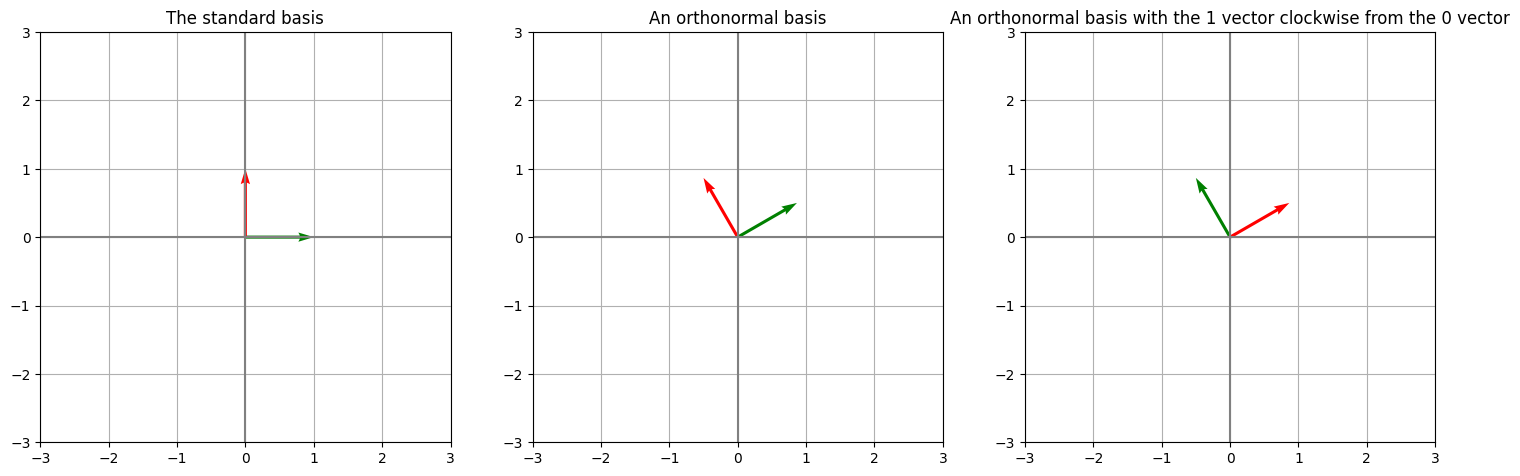

In [12]:
fig,ax = LADS2DSquare(ncols=3,xlow=-3,xhigh=3)
# Here is the standard basis in 2D

e0 = LADSStdBasis(0,dim=2)
e1 = LADSStdBasis(1,dim=2)

ax[0].LADS2DDrawVector(e0)
ax[0].LADS2DDrawVector(e1,'red')
ax[0].set_title("The standard basis")

# We'll rotate by pi/6 to get a new orthonormal basis

b0 = RotationMatrix2D(np.pi/6) @ e0
b1 = RotationMatrix2D(np.pi/6) @ e1

ax[1].LADS2DDrawVector(b0)
ax[1].LADS2DDrawVector(b1,'red')
ax[1].set_title("An orthonormal basis")

# Here is an example where we make the red vector b1 come before the green vector b0 in "counterclockwise ordering",
# also called the right hand rule

bb1 = RotationMatrix2D(np.pi/6) @ e0
bb0 = RotationMatrix2D(np.pi/6) @ e1

ax[2].LADS2DDrawVector(bb0)
ax[2].LADS2DDrawVector(bb1,'red')
ax[2].set_title("An orthonormal basis with the 1 vector clockwise from the 0 vector")

Let's check that in any of these bases, we can get the coordinates of a vector using the dot product formula
$$
v = (v \cdot b0) * b0 + (v \cdot b1) * b1.
$$

Text(0.5, 1.0, '(bb0@v)*bb0 + (bb1@v)*b1 in blue')

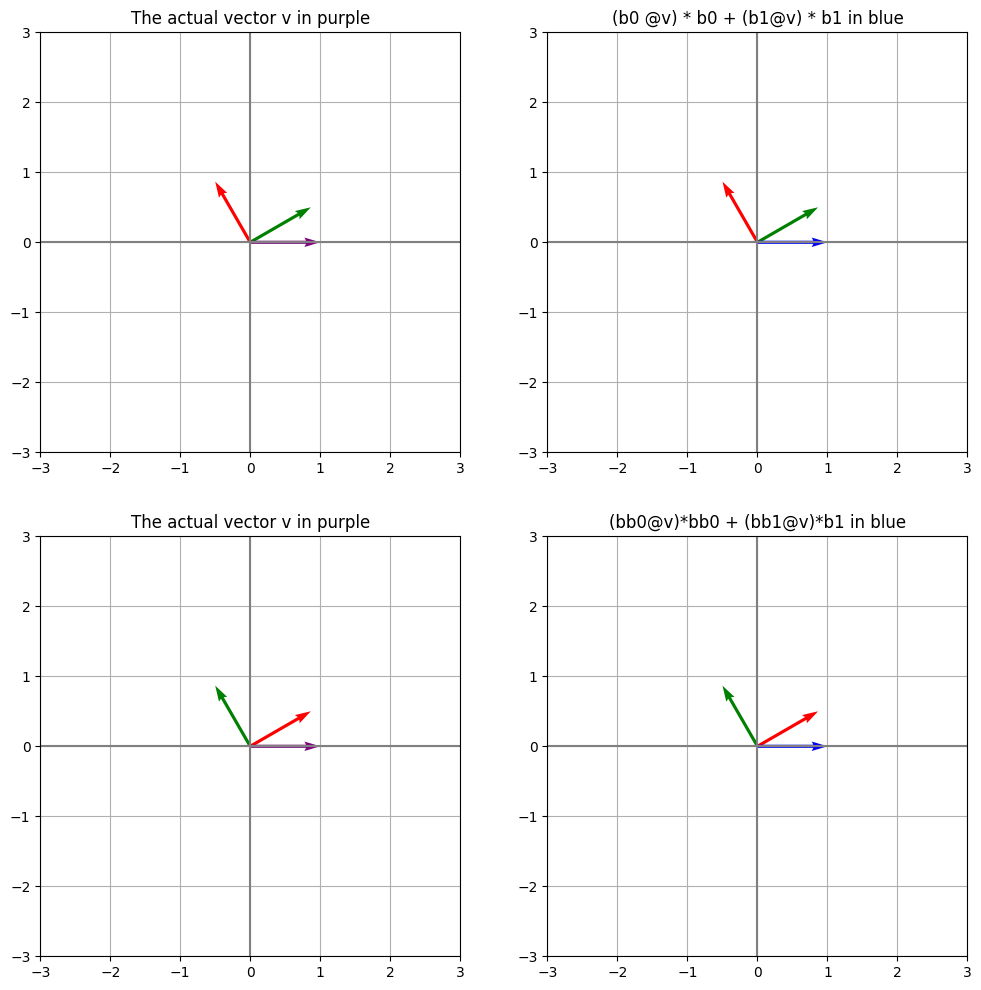

In [13]:
fig,ax = LADS2DSquare(ncols=2,nrows=2,xlow=-3,xhigh=3)

# Here is a random vector

v = rng.integers(low=-3,high=3,size=(2))

# Here is the standard basis in 2D

b0 = RotationMatrix2D(np.pi/6) @ e0
b1 = RotationMatrix2D(np.pi/6) @ e1

ax[0,0].LADS2DDrawVector(b0)
ax[0,0].LADS2DDrawVector(b1,'red')
ax[0,0].LADS2DDrawVector(v,'purple')
ax[0,0].set_title("The actual vector v in purple")

vreconstructed = (b0@v) * b0 + (b1@v) * b1

ax[0,1].LADS2DDrawVector(b0)
ax[0,1].LADS2DDrawVector(b1,'red')
ax[0,1].LADS2DDrawVector(vreconstructed,'blue')
ax[0,1].set_title("(b0 @v) * b0 + (b1@v) * b1 in blue")

# The dot product formula works with the other ordering of the basis.

bb1 = RotationMatrix2D(np.pi/6) @ e0
bb0 = RotationMatrix2D(np.pi/6) @ e1



ax[1,0].LADS2DDrawVector(bb0)
ax[1,0].LADS2DDrawVector(bb1,'red')
ax[1,0].LADS2DDrawVector(v,'purple')
ax[1,0].set_title("The actual vector v in purple")

vreconstructed = (bb0@v) * bb0 + (bb1@v) * bb1

ax[1,1].LADS2DDrawVector(bb0)
ax[1,1].LADS2DDrawVector(bb1,'red')
ax[1,1].LADS2DDrawVector(vreconstructed,'blue')
ax[1,1].set_title("(bb0@v)*bb0 + (bb1@v)*b1 in blue")



#### **Do it:**
Make yourself a different 2D orthonormal basis with vectors labeled $b0$ and $b1$. Then make two 2D vectors $v$ and $w$, and check that the dot product method gives the coordinates of $v$ and $w$ in the basis $b0$ and $b1$. Display $v$ and $w$ graphically, and also display graphically their reconstructions using the dot product fomula.

Text(0.5, 1.0, '(bb0@w)*bb0 + (bb1@w)*b1 in blue')

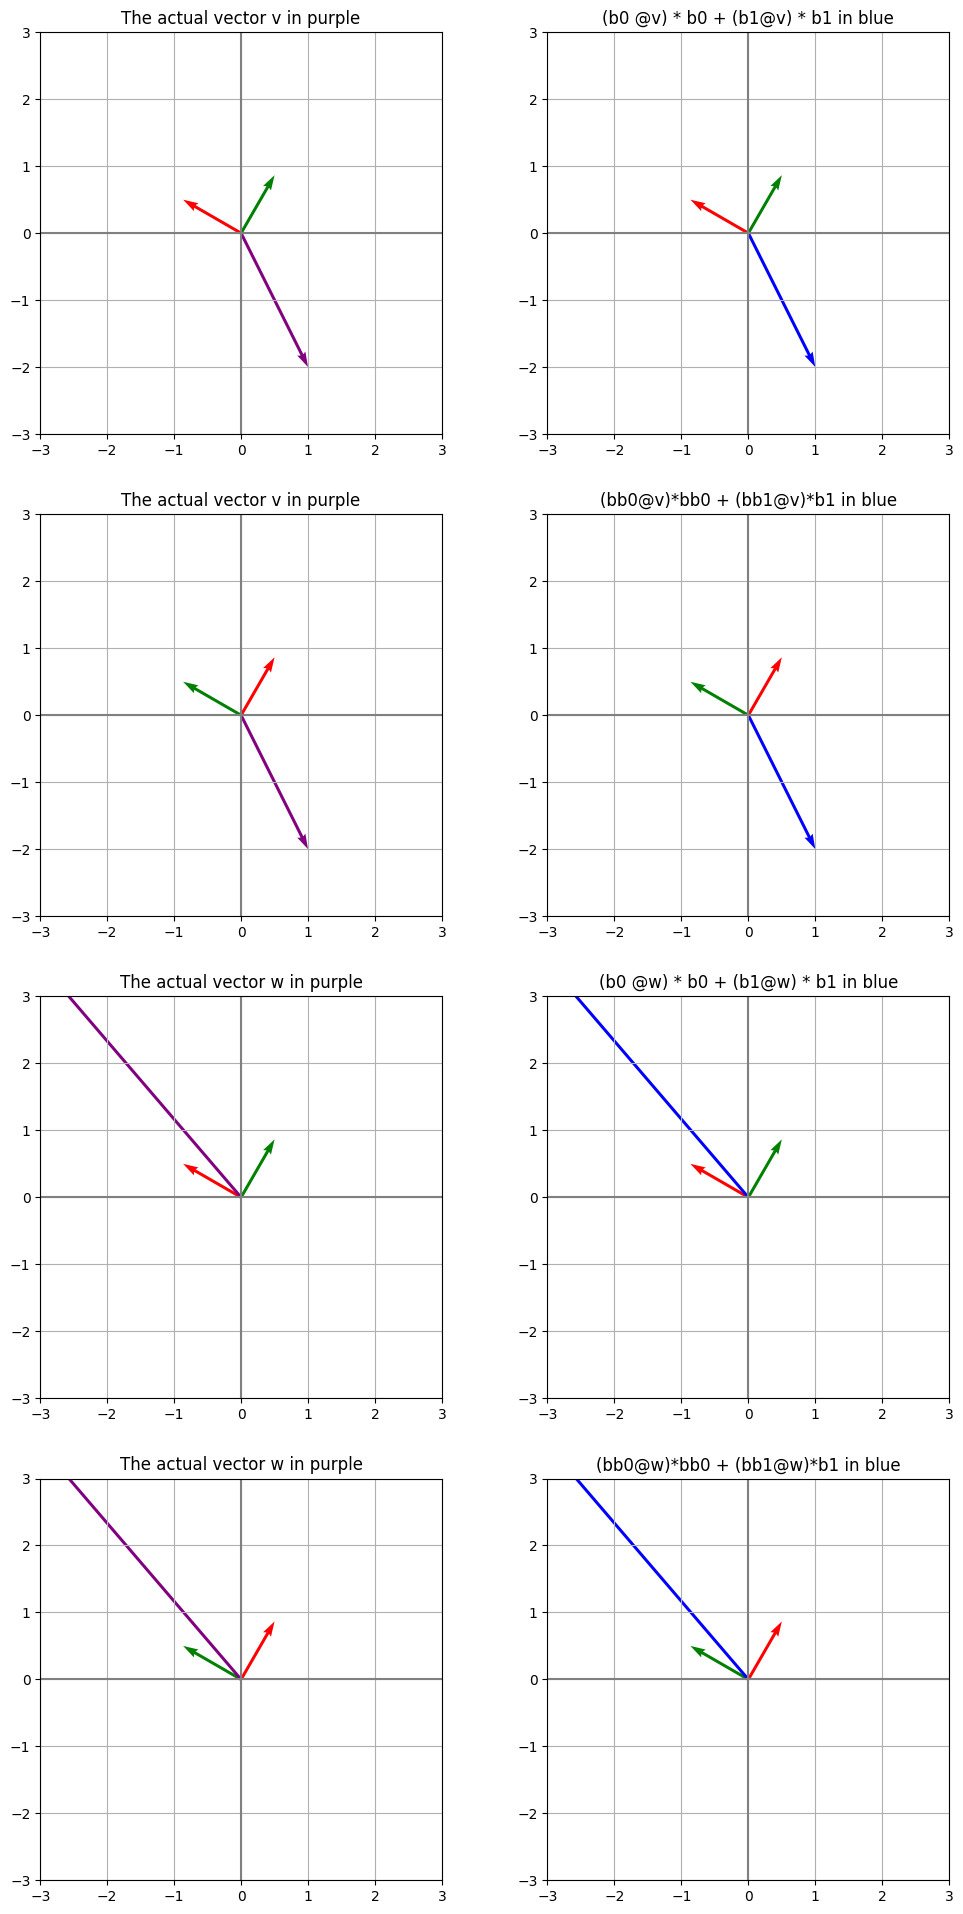

In [14]:
## you can do the work in this code cell
fig,ax = LADS2DSquare(ncols=2,nrows=4,xlow=-3,xhigh=3)

# Here is a random vector

v = (1, -2)
w = (-3, 3.5)

# Here is the standard basis in 2D

b0 = RotationMatrix2D(np.pi/3) @ e0
b1 = RotationMatrix2D(np.pi/3) @ e1

ax[0,0].LADS2DDrawVector(b0)
ax[0,0].LADS2DDrawVector(b1,'red')
ax[0,0].LADS2DDrawVector(v,'purple')
ax[0,0].set_title("The actual vector v in purple")

vreconstructed = (b0@v) * b0 + (b1@v) * b1

ax[0,1].LADS2DDrawVector(b0)
ax[0,1].LADS2DDrawVector(b1,'red')
ax[0,1].LADS2DDrawVector(vreconstructed,'blue')
ax[0,1].set_title("(b0 @v) * b0 + (b1@v) * b1 in blue")

# The dot product formula works with the other ordering of the basis.

bb1 = RotationMatrix2D(np.pi/3) @ e0
bb0 = RotationMatrix2D(np.pi/3) @ e1

ax[1,0].LADS2DDrawVector(bb0)
ax[1,0].LADS2DDrawVector(bb1,'red')
ax[1,0].LADS2DDrawVector(v,'purple')
ax[1,0].set_title("The actual vector v in purple")

vreconstructed = (bb0@v) * bb0 + (bb1@v) * bb1

ax[1,1].LADS2DDrawVector(bb0)
ax[1,1].LADS2DDrawVector(bb1,'red')
ax[1,1].LADS2DDrawVector(vreconstructed,'blue')
ax[1,1].set_title("(bb0@v)*bb0 + (bb1@v)*b1 in blue")

# vector w

ax[2,0].LADS2DDrawVector(b0)
ax[2,0].LADS2DDrawVector(b1,'red')
ax[2,0].LADS2DDrawVector(w,'purple')
ax[2,0].set_title("The actual vector w in purple")

wreconstructed = (b0@w) * b0 + (b1@w) * b1

ax[2,1].LADS2DDrawVector(b0)
ax[2,1].LADS2DDrawVector(b1,'red')
ax[2,1].LADS2DDrawVector(wreconstructed,'blue')
ax[2,1].set_title("(b0 @w) * b0 + (b1@w) * b1 in blue")


ax[3,0].LADS2DDrawVector(bb0)
ax[3,0].LADS2DDrawVector(bb1,'red')
ax[3,0].LADS2DDrawVector(w,'purple')
ax[3,0].set_title("The actual vector w in purple")

wreconstructed = (bb0@w) * bb0 + (bb1@w) * bb1

ax[3,1].LADS2DDrawVector(bb0)
ax[3,1].LADS2DDrawVector(bb1,'red')
ax[3,1].LADS2DDrawVector(wreconstructed,'blue')
ax[3,1].set_title("(bb0@w)*bb0 + (bb1@w)*b1 in blue")


#### Leave this text cell for the grader.

Note that "dot product" method of finding coordinates does **not** work if the basis is not orthonormal.

b0 and b1 are not orthogonal because b0 @ b1 =  -4 .
The dot product formula gives coordinates  -10  and  4 . But this doesn't work.
The true coordinates of v in the basis b0, b1 are  -1.0  and  -2.0816681711721685e-17 .


Text(0.5, 1.0, 'The orange vector was found using la.solve.')

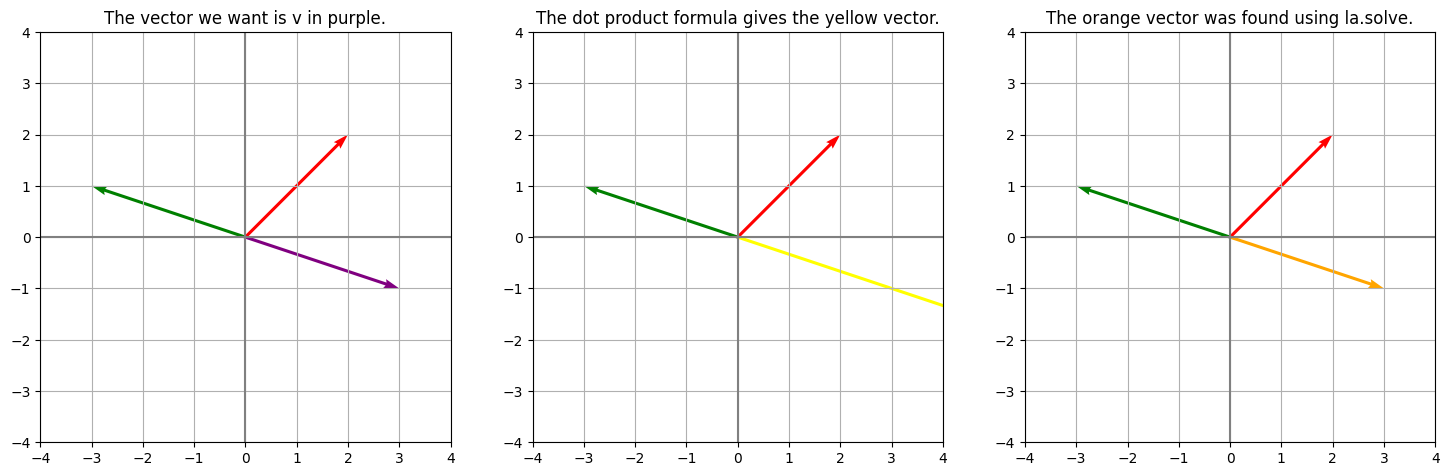

In [15]:
fig,ax = LADS2DSquare(ncols=3,xlow=-4,xhigh=4)

# Here is another basis, not orthonormal

b0 = np.array([-3,1])
b1 = np.array([2,2])

# Check that b0 and b1 are NOT orthogonal

print("b0 and b1 are not orthogonal because b0 @ b1 = ", b0@b1,".")
# Here is a random vetor v

#v = rng.integers(low=-4,high=4,size=(2))
v = np.random.randint(low=-4,high=4,size=(2))

# Here's the attempt at v using the dot product formula

print("The dot product formula gives coordinates ",b0@v," and ",b1@v,". But this doesn't work.")
vattempted = (b0@v) * b0 + (b1*v) * b1

# On the left we'll draw v, and in the middle we'll draw the attempt at v using the dot product formula
ax[0].LADS2DDrawVector(b0)
ax[0].LADS2DDrawVector(b1,'red')
ax[0].LADS2DDrawVector(v,'purple')
ax[0].set_title("The vector we want is v in purple.")

ax[1].LADS2DDrawVector(b0)
ax[1].LADS2DDrawVector(b1,'red')
ax[1].LADS2DDrawVector(vattempted,'yellow')
ax[1].set_title("The dot product formula gives the yellow vector.")

# We can still find coordinates of v in the basis b0, b1, but we have to use la.solve. We'll draw that on the right.
M=np.array([b0,b1]).T
c = la.solve(M,v)
print("The true coordinates of v in the basis b0, b1 are ", c[0], " and ",c[1],".")

ax[2].LADS2DDrawVector(b0)
ax[2].LADS2DDrawVector(b1,'red')
ax[2].LADS2DDrawVector(M@c,'orange')
ax[2].set_title("The orange vector was found using la.solve.")

## Moving between orthonormal bases doesn't distort images

The fact that othonormal bases look like the standad basis (the vectors are perpendicular and have length 1) means that using the coordinates from one orthonormal basis with another orthonormal basis doesn't distort images; it just places them differently. Let's see what this means  with two examples. In these examples, it will be very valuable to remember the column view of matrix multiplication: if $B$ is a 2 by 2 matrix with columns
$$
B = \begin{bmatrix}
| & | \\
b0&b1 \\
| & |
\end{bmatrix},
$$
and if $Z$ is a $2$ by $n$ matrix whose $j$ column is 
$$
Z[:,j] = \begin{bmatrix} Z[0,j]\\Z[1,j] \end{bmatrix},
$$
then $BZ$ or $B@Z$ is the 2 by $n$ matrix whose $j$ column is
$$
   Z[0,j] * b0 + Z[1,j] * b1.
$$
That is, the $j$ column of $BZ$ is a linear combination of the columns of $B$ with entries given by the entries of the $j$ column of $Z$. 

We'll use this observation this way: we'll have a basis $b0, b1$, and we'll have a large number (say, 100) of $2D$ vectors. For each such vector $v$, we want to see what the linear combination $v[0] * b0 + v[1] * b1$ looks like. The easiest way to do that in Python is to put the vectors $v$ into a 2 by 100 matrix $Z$, and make the basis $b0, b1$ the columns of a matrix $B$. Then the $j$ column of BZ will be $Z[0,j] * b0 + Z[1,j] * b1.$

In the code below, we'll draw three circles by putting the coordinates of those circles in 2 by 100 matrices.

(2, 100)
(2, 100)
(2, 100)


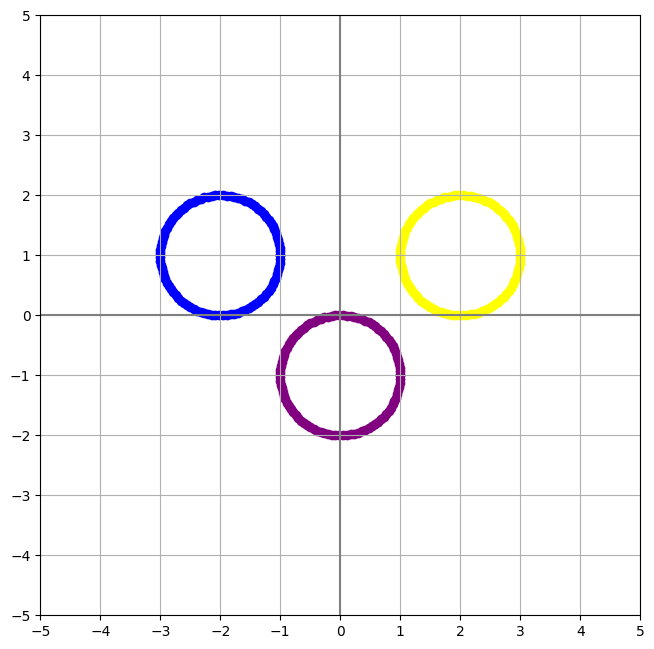

In [16]:
# First we'll make a colorful plot
fig,ax = LADS2DSquare(xlow=-5,xhigh=5)

# svec holds 100 numbers evenly distributed between 0 and 2 pi: one hundred angles in radians.
svec = np.linspace(0,2*np.pi,100)

#xleft a list of 100 x-coordinates of unit circle, moved left by 2
xleft = [np.cos(s)-2 for s in svec]

#xmid is the list of x-coordinates of the unit circle
xmid = [np.cos(s) for s in svec]

#xright is the list of x-coordinates of the unit circle, moved right by 2
xright=[np.cos(s)+2 for s in svec]

#yleft is the y-coordinates of the unit circle, moved up by 1
yleft = [np.sin(s)+1 for s in svec]

#ymid is the coordinates of the unit cicle, moved down by 1
ymid = [np.sin(s)-1 for s in svec]

#yright is the y-coordinates of the unit circle, moved up by 1.
yright = [np.sin(s)+1 for s in svec]

#leftcircle is a 2-row by 100-column matrix. Each column is the coordinates of a point on the unit circle moved left by 2 and up by 1.
leftcircle = np.array([xleft, yleft])

#midcircle isa 2 by 100 matrix. Each column is the coordinates of a point on the unit ricle, moved down by 1.
midcircle = np.array([xmid,ymid])


rightcircle = np.array([xright,yright])

#Let's look at the shapes of leftcircle, midcircle, rightcircle. 
# Each of "leftcircle" "midcircle" "rightcircle" is a 2 by 100 matrix. The first row is 100 x-coordinates for a circle. 
# The second row is 100 y-coordinates for a circle

print(leftcircle.shape)
print(midcircle.shape)
print(rightcircle.shape)

# ax.scatter is a method of matplotlib's axes. It draws a "scatter plot" of points at the coordiantesyou specify.
 
ax.scatter(*leftcircle,c='blue')
ax.scatter(*midcircle,c='purple')
ax.scatter(*rightcircle,c='yellow')




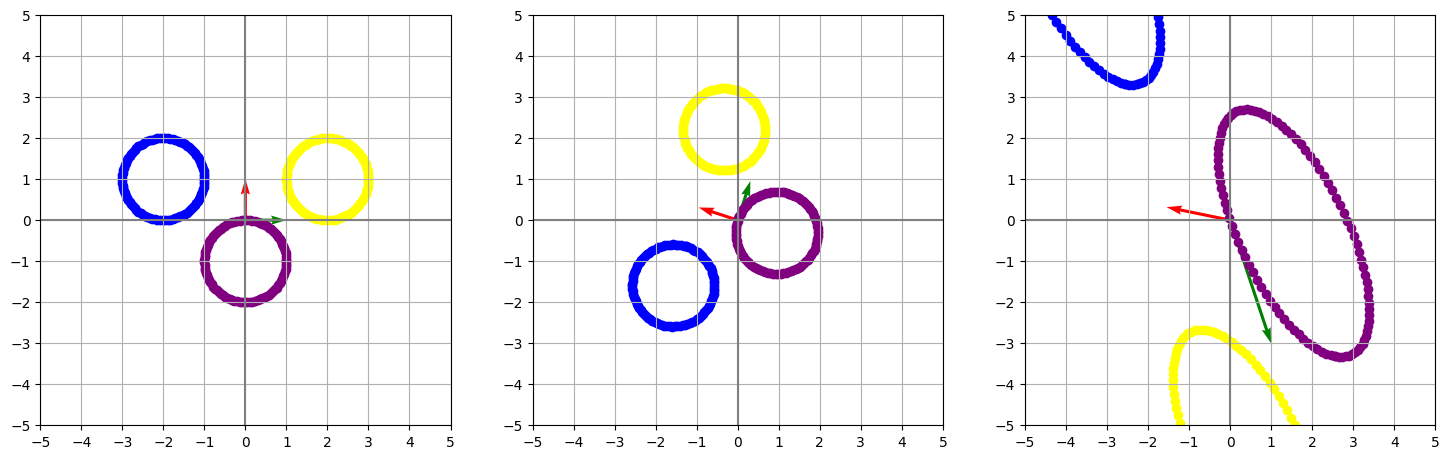

In [17]:
# Now we'll use the same x and y coordinates, but we'll use the coordinates to take linear combinations of 
# an orthonormal basis 

# The simplest way to do this for each of the 100 vectors in leftcircle, midcircle, rightcircle is to make a matrix
# B with columns b0, b1 and C with columns c0, c1, and then multiply those matrices against each of the matrices
# leftcircle, midcicle, rightcircle.

# Here is an orthonormal basis b0, b1
b0 = RotationMatrix2D(2*np.pi/5) @ e0
b1 = RotationMatrix2D(2*np.pi/5) @ e1

fig,ax=LADS2DSquare(ncols=3,xlow=-5,xhigh=5)

#On the left axes, we'll draw the circles as we drew them above. We'll also draw the standard basis
ax[0].LADS2DDrawVector(e0)
ax[0].LADS2DDrawVector(e1,'red')
ax[0].scatter(*leftcircle,c='blue')
ax[0].scatter(*midcircle,c='purple')
ax[0].scatter(*rightcircle,c='yellow')

#On the middle axis, we'll use the same coordiantes to make linear combinations of b0 and b1. 
# M is the 2 by 2 matrix with columns b0, b1
M = np.array([b0,b1]).T

ax[1].LADS2DDrawVector(b0)
ax[1].LADS2DDrawVector(b1,'red')
ax[1].scatter(*(M@leftcircle),c='blue')
ax[1].scatter(*(M@midcircle),c='purple')
ax[1].scatter(*(M@rightcircle),c='yellow')

# On the right axis, we'll use the basis c0, c1 from above; it is not orthonormal
# C is the matrix with columnc c0, c1
c0 = np.array([1,-3])
c1 = 0.5* RotationMatrix2D(4* np.pi/3)@c0
C = np.array([c0,c1]).T

ax[2].LADS2DDrawVector(c0)
ax[2].LADS2DDrawVector(c1,'red')
ax[2].scatter(*(C@leftcircle),c='blue')
ax[2].scatter(*(C@midcircle),c='purple')
ax[2].scatter(*(C@rightcircle),c='yellow')

#### **Do it:** 
Make another orthonormal basis, and apply it to `leftcircle`, `midcircle`, and `rightcircle`. Plot the result. Check that the new image is not distorted from the original. 

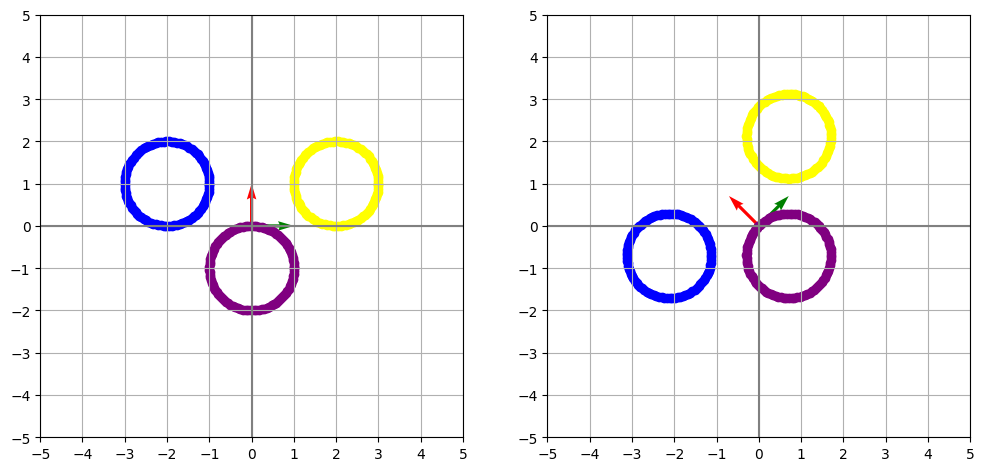

In [19]:
# You can do you work in this code cell
fig,ax=LADS2DSquare(ncols=2,xlow=-5,xhigh=5)

#On the left axes, we'll draw the circles as we drew them above. We'll also draw the standard basis
ax[0].LADS2DDrawVector(e0)
ax[0].LADS2DDrawVector(e1,'red')
ax[0].scatter(*leftcircle,c='blue')
ax[0].scatter(*midcircle,c='purple')
ax[0].scatter(*rightcircle,c='yellow')

b0 = RotationMatrix2D(np.pi/4) @ e0
b1 = RotationMatrix2D(np.pi/4) @ e1

M = np.array([b0,b1]).T

ax[1].LADS2DDrawVector(b0)
ax[1].LADS2DDrawVector(b1,'red')
ax[1].scatter(*(M@leftcircle),c='blue')
ax[1].scatter(*(M@midcircle),c='purple')
ax[1].scatter(*(M@rightcircle),c='yellow')

#### Leave this text cell for the grader.

## Moving between orthonormal frames

Remember that if $M$ is an $n\times k$ matrix with columns $c_0, ..., c_{k-1}$, and if $e_0,...,e_{k-1}$ is the standard basis in dimension $k$, then 
$$
M e_j = c_j.
$$
That is, $M$ applied to the $j$ standard basis vector returns the $j$ column of $M$. "M carries the standard basis $e_0,\ldots,e_{k-1}$ to its columns $c_0,\ldots,c_{k-1}$

Above, we made orthonormal bases by applying a matrix to the standard basis. In fact the orthonormal basis was the same as the columns of our matrix.

The zero column of B:  [-0.5        0.8660254]
The zero vector in our basis:  [-0.5        0.8660254]
The one column of B: , [-0.8660254 -0.5      ]
The one column of our basis: [-0.8660254 -0.5      ]


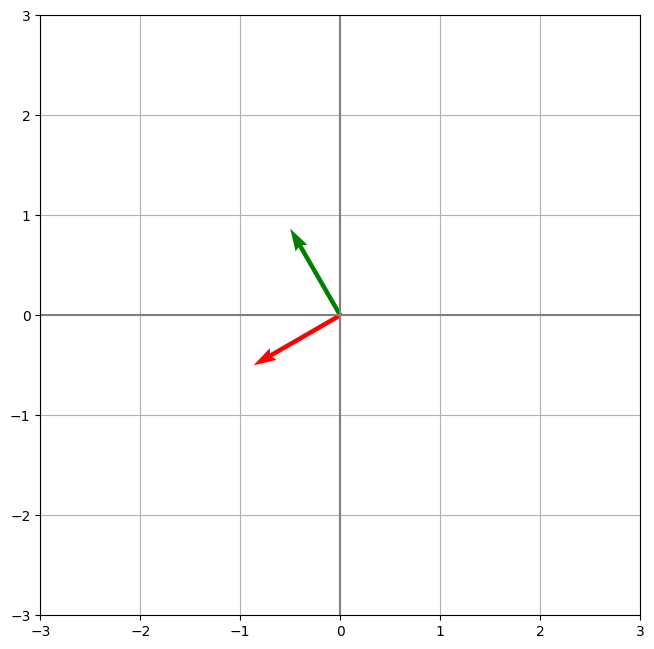

In [20]:
# Here is an orthonormal basis b0, b1
B = RotationMatrix2D(2*np.pi/3)
b0 = B @ e0
b1 = B @ e1 

fig,ax=LADS2DSquare(xlow=-3,xhigh=3)

ax.LADS2DDrawVector(b0)
ax.LADS2DDrawVector(b1,'red')

print("The zero column of B: ",B[:,0])
print("The zero vector in our basis: ",b0)
print("The one column of B: ,",B[:,1])
print("The one column of our basis:",b1)



Let's suppose that $b_0,\ldots, b_{n-1}$ is an orthonormal basis. Then we can make the matrix $B$ with columns the vectors of our basis:
$$
B = \begin{bmatrix}
| & & | \\
b_0 & & b_{n-1}\\
| &  & |
\end{bmatrix}
$$
We've just noted that $B$ takes the standard basis in dimension $n$ to this basis: $Be_j = b_j$. 

It turns out that the transpose $B^T$ (in Python $B.T$) reverses this process: $B^T b_j = e_j$. Let's see this in our 2D case.

In [21]:
# Here is an orthonormal basis b0, b1

B = RotationMatrix2D(2*np.pi/3)
b0 = B @ e0
b1 = B @ e1 


# To be safe let's check again that the columns of B are b0 and b1.

print("The zero column of B: ",B[:,0])
print("The zero vector in our basis: ",b0)
print("The one column of B: ,",B[:,1])
print("The one column of our basis:",b1)

# Now apply B.T to b0 and b1.

print(" B.T @ b0 = ", B.T@b0)
print(" B.T @ b1 = ", B.T@b1)


The zero column of B:  [-0.5        0.8660254]
The zero vector in our basis:  [-0.5        0.8660254]
The one column of B: , [-0.8660254 -0.5      ]
The one column of our basis: [-0.8660254 -0.5      ]
 B.T @ b0 =  [1.00000000e+00 2.57628149e-17]
 B.T @ b1 =  [2.57628149e-17 1.00000000e+00]


Why did this happen? Because of the dot product view of applying a matrix to a vector: $B^T$ has rows $b_0,...,b_{n-1}$:
$$
B^T = \begin{bmatrix}
-- & b_0 & -- \\
    & \vdots & \\
-- & b_{n-1} & --
\end{bmatrix}.
$$
If $v$ is any $n$-vector, then 
$$
B^T v = \begin{bmatrix}
 b_0\cdot v \\
\vdots\\
b_{n-1} \cdot v
\end{bmatrix}.
$$
Since $b_0,\ldots,b_{n-1}$ is an orthonormal basis, we have $b_i\cdot b_j = 0$ for $i\neq j$, and $b_i \cdot b_i = 1.$ This tells us that $B.T b_j = e_j$.

This is very important and useful fact.

>**Fact:** If $B$ is a matrix whose columns are an $n$-dimensional orthonormal basis, then $B.T @ B$ is the $n\times n$ identity matrix. We can also say that $B.T = B^{-1}$, or "$B.T$ is the inverse of $B$." We can also say that, if $b_0,\ldots,b_{n-1}$ are the columns of $B$, then $Bb_j = e_j$.

We can put it one more way: 
>"$B$ sends the standard basis to the basis $b_0,...,b_{n-1}$, and $B.T$ reverses this effect, sending the basis $b_0,\ldots,b_{n-1}$ to the standard basis."

Let's see that reversal, not just on the basis vectors but on any vector.

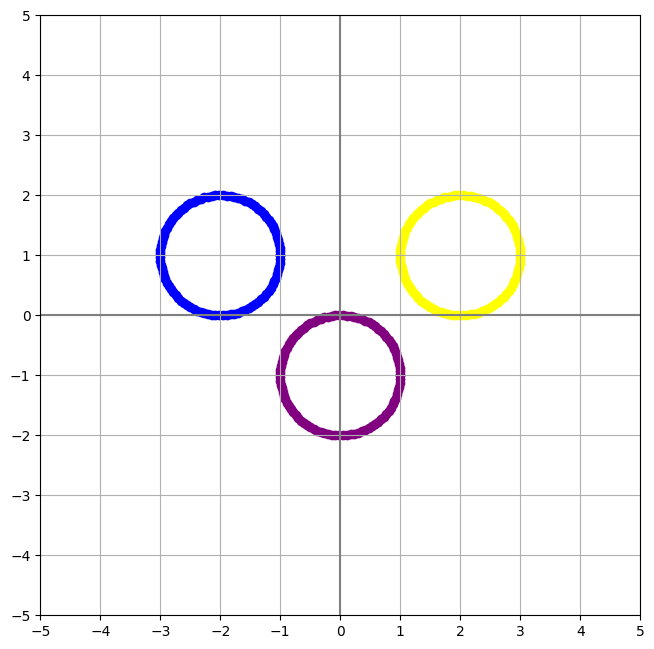

In [22]:
# Let's make sure that our circles from above are defined.
fig,ax = LADS2DSquare(xlow=-5,xhigh=5)

svec = np.linspace(0,2*np.pi,100)
xleft = [np.cos(s)-2 for s in svec]
xmid = [np.cos(s) for s in svec]
xright=[np.cos(s)+2 for s in svec]

yleft = [np.sin(s)+1 for s in svec]
ymid = [np.sin(s)-1 for s in svec]
yright = [np.sin(s)+1 for s in svec]

leftcircle = np.array([xleft, yleft])
midcircle = np.array([xmid,ymid])
rightcircle = np.array([xright,yright])

ax.scatter(*leftcircle,c='blue')
ax.scatter(*midcircle,c='purple')
ax.scatter(*rightcircle,c='yellow')





Text(0.5, 1.0, "And then after applying B.T we're back again.")

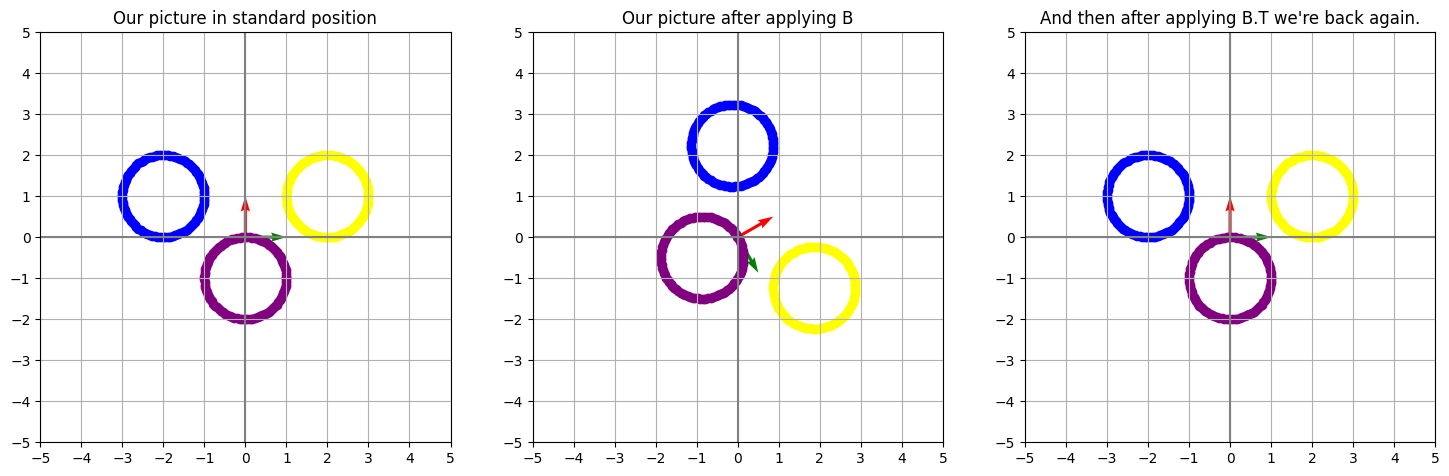

In [23]:
# Now let's make an orthonormal basis with its columns in a matrix B. We'll apply B and then B.T
# and get back where we started

# Here is a matrix B with orthonormal columns b_0 b_1

B = RotationMatrix2D (-np.pi/3)
b0 = B @ e0
b1 = B @ e1 

fig,ax=LADS2DSquare(ncols=3,xlow=-5,xhigh=5)

#On the left axes, we'll draw the circles as we drew them above. We'll also draw the standard basis
ax[0].LADS2DDrawVector(e0)
ax[0].LADS2DDrawVector(e1,'red')
ax[0].scatter(*leftcircle,c='blue')
ax[0].scatter(*midcircle,c='purple')
ax[0].scatter(*rightcircle,c='yellow')
ax[0].set_title("Our picture in standard position")

#On the middle axis, we'll use the same coordiantes to make linear combinations of b0 and b1, 
#by applying the matrix B.

Bleft = B@leftcircle
Bmid =  B@midcircle
Bright = B@rightcircle

ax[1].LADS2DDrawVector(b0)
ax[1].LADS2DDrawVector(b1,'red')
ax[1].scatter(*Bleft ,c='blue')
ax[1].scatter(*Bmid,c='purple')
ax[1].scatter(*Bright,c='yellow')
ax[1].set_title("Our picture after applying B")

# On the right axis, we'll draw B.T applied to the transformed picture
# B is a matrix with columns b0, b1

BTBleft = B.T @ Bleft 
BTBmid = B.T @ Bmid
BTBright = B.T @ Bright

ax[2].LADS2DDrawVector(B.T@b0)
ax[2].LADS2DDrawVector(B.T@b1,'red')
ax[2].scatter(*BTBleft,c='blue')
ax[2].scatter(*BTBmid,c='purple')
ax[2].scatter(*BTBright,c='yellow')
ax[2].set_title("And then after applying B.T we're back again.")



#### **Do it:**
Make a different matrix $B$ whose columns are an orthonormal basis $b_0, b_1$. Check that $B.T b_i = e_i$. Make sure to print the values to show it.

Apply your matrix $B$ to our image, and then apply $B.T$ to that image, and see that you get back where you started.




The zero column of B:  [0.70710678 0.70710678]
The zero vector in our basis:  [0.70710678 0.70710678]
The one column of B: , [-0.70710678  0.70710678]
The one column of our basis: [-0.70710678  0.70710678]
 B.T @ b0 =  [ 1.00000000e+00 -1.01465364e-17]
 B.T @ b1 =  [-1.01465364e-17  1.00000000e+00]


Text(0.5, 1.0, "And then after applying B.T we're back again.")

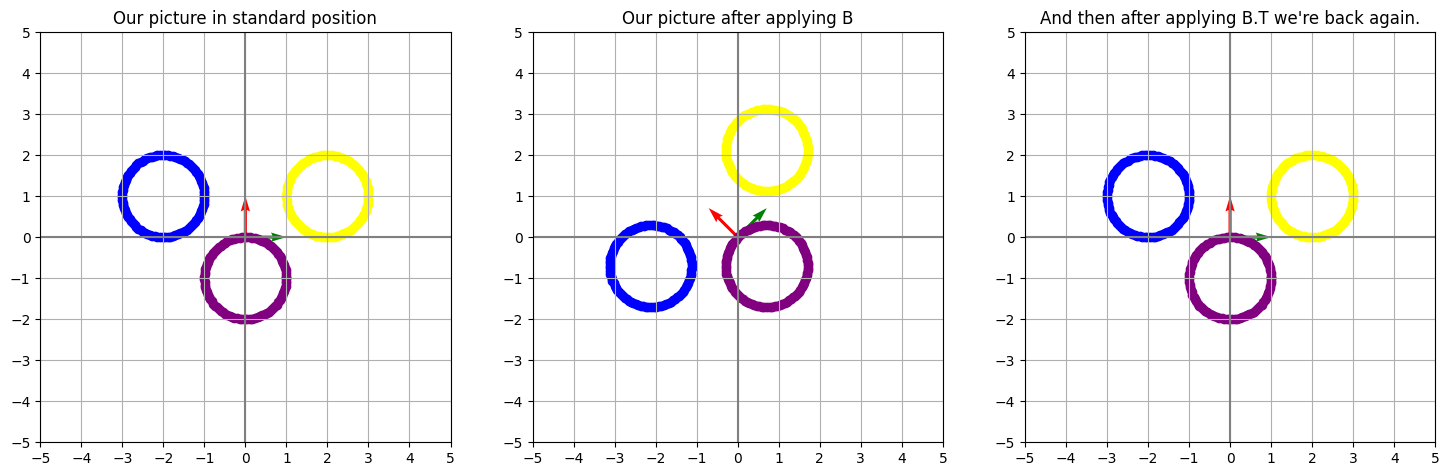

In [24]:
B = RotationMatrix2D(np.pi/4)
b0 = B @ e0
b1 = B @ e1 


# To be safe let's check again that the columns of B are b0 and b1.

print("The zero column of B: ",B[:,0])
print("The zero vector in our basis: ",b0)
print("The one column of B: ,",B[:,1])
print("The one column of our basis:",b1)

# Now apply B.T to b0 and b1.

print(" B.T @ b0 = ", B.T@b0)
print(" B.T @ b1 = ", B.T@b1)

fig,ax=LADS2DSquare(ncols=3,xlow=-5,xhigh=5)

#On the left axes, we'll draw the circles as we drew them above. We'll also draw the standard basis
ax[0].LADS2DDrawVector(e0)
ax[0].LADS2DDrawVector(e1,'red')
ax[0].scatter(*leftcircle,c='blue')
ax[0].scatter(*midcircle,c='purple')
ax[0].scatter(*rightcircle,c='yellow')
ax[0].set_title("Our picture in standard position")

#On the middle axis, we'll use the same coordiantes to make linear combinations of b0 and b1, 
#by applying the matrix B.

Bleft = B@leftcircle
Bmid =  B@midcircle
Bright = B@rightcircle

ax[1].LADS2DDrawVector(b0)
ax[1].LADS2DDrawVector(b1,'red')
ax[1].scatter(*Bleft ,c='blue')
ax[1].scatter(*Bmid,c='purple')
ax[1].scatter(*Bright,c='yellow')
ax[1].set_title("Our picture after applying B")

# On the right axis, we'll draw B.T applied to the transformed picture
# B is a matrix with columns b0, b1

BTBleft = B.T @ Bleft 
BTBmid = B.T @ Bmid
BTBright = B.T @ Bright

ax[2].LADS2DDrawVector(B.T@b0)
ax[2].LADS2DDrawVector(B.T@b1,'red')
ax[2].scatter(*BTBleft,c='blue')
ax[2].scatter(*BTBmid,c='purple')
ax[2].scatter(*BTBright,c='yellow')
ax[2].set_title("And then after applying B.T we're back again.")

#### Leave this cell for the grader.

#### **Do it:** 
Check that the tranpose of $M$ doesn't reverse the effect of $M$ if the columns of $M$ aren't orthonormal. Make two vectors $c_0$ and $c_1$ that are *not* orthonormal, and make them the columns of a matrix $M$. Check that $M.T @ M$ does *not* send $e_j$ to $e_j$.

In [25]:
# you can do your work in this code cell. Remember that to get the 2D stanard basis you can use
e0 = LADSStdBasis(0,dim=2)
e1 = LADSStdBasis(1,dim=2)
# Remember that once you've made c0 and c1, you can make them the columns of M using this: 

c0 = np.array([1, -3])
c1 = np.array([3, 3])

M = np.array([c0,c1]).T

print("The zero vector in our basis: ",c0)
print("The one column of our basis:",c1)

# Now apply M.T to c0 and c1.

print(" M.T @ M = ", M.T@c0)
print(" c0 = ", c0)
print(" c1 = ", c1)


The zero vector in our basis:  [ 1 -3]
The one column of our basis: [3 3]
 M.T @ M =  [10 -6]
 c0 =  [ 1 -3]
 c1 =  [3 3]


#### Leave this cell for the grader.

All this means
>Fact: If I have *two* orthonormal bases in dimension $n$, say $b_0,\ldots,b_{n-1}$ and $c_0,...,c_{n-1}$, it is easy to write down the matrix $M$ that carries $b_j$ to $c_j$: 
$$
M = C B^T \text{ or in Python } C @ B.T.
$$
After all, $B.T$ carries $b_j$ to $e_j$, and $C$ carries $e_j$ to $c_j$. And matrix multiplication correspondes to composition of operations, so the product does both steps with one matrix and carries $b_j$ to $c_j$.

Let's see this in action.

Text(0.5, 1.0, 'C@B.T applied to the basis b0, b1')

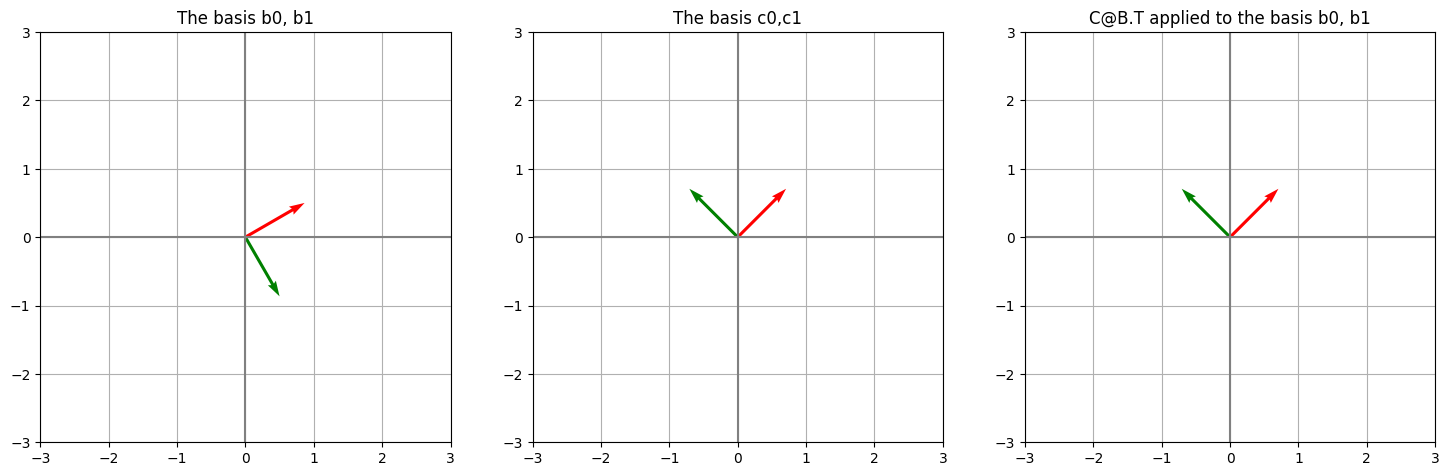

In [26]:
# Let's make an orthonormal basis with its columns in a matrix B. 

# Here is a matrix B with orthonormal columns b_0 b_1

B = RotationMatrix2D (-np.pi/3)
b0 = B @ e0
b1 = B @ e1 

# And let's make an orthonormal basis with columns in a matrix C. We'll make c0 and c1 in
# clockwise order to mix things up.

e0 = LADSStdBasis(0,dim=2)
e1 = LADSStdBasis(1,dim=2)

c1 = RotationMatrix2D(np.pi/4)@e0
c0 = RotationMatrix2D(np.pi/4)@e1

C = np.array([c0,c1]).T

fig,ax=LADS2DSquare(ncols=3,xlow=-3,xhigh=3)

#On the left axes, we'll draw the basis b0, b1

ax[0].LADS2DDrawVector(b0)
ax[0].LADS2DDrawVector(b1,'red')
ax[0].set_title("The basis b0, b1")

#On the middle axis, we'll draw the basis c0, c1

ax[1].LADS2DDrawVector(c0)
ax[1].LADS2DDrawVector(c1,'red')
ax[1].set_title("The basis c0,c1")

# On the right axis, we'll draw C@B.T applied to the basis b0, b1

ax[2].LADS2DDrawVector(C@B.T@b0)
ax[2].LADS2DDrawVector(C @ B.T@b1,'red')
ax[2].set_title("C@B.T applied to the basis b0, b1")




## Orthogonal projection

### Approximating a vector by a linear combination of orthonormal vectors, using the dot product

Now suppose that $h_0,...,h_{k-1}$ is an orthonormal set of $n$-dimensional vectors, but $k<n$, so they are NOT a basis for $\mathbb{R}^n$. If $v$ is another $n$-dimensional vector, then it may not be possible to write $v$ as a linear combination of the $b$s. 

But you can still find the *closest* vector to the span of the $h$s. This closest vector is the best approximation you can make to $v$ using a linear combination of the $h$s. It is awkwardly called the "orthogonal projection of $v$ onto the span of the $h$s". We'll use $P_{h_{0},...,h_{k-1}}(v)$ for this orthogonal projection. That's hard to read, so we'll make the matrix $H$ with columns $h_{0},...,h_{k-1}$,

$$
H = \begin{bmatrix} | & & | \\
                    h_0 & \ldots & h_{k-1} \\
                    | & & | 
    \end{bmatrix}
$$

and also write $P_H(v)$ for the orthogonal projection. 

A very convenient property of orthonormal bases is that there is a simple forula for this approximation.

>**Fact:** The closest approximation to $v$ by a linear combination of the $h$s is
$$
 P_{H}(v) = (h_0 \cdot v) h_0 + \ldots + (h_{k-1} \cdot v) h_{k-1}
$$
>or, using Python notation `@` for dot product and `*` for scalar multiplication,
$$
 P_{H}(v) = (h_0 @ v) * h_0 + \ldots + (h_{k-1} @ v) * h_{k-1}
$$

That's the "dot product" formula for orthogonal projection. 

### Using matrix multiplication to check orthonormality and to carry out orthogonal projection

If $h_0,...,H_{k-1}$ is a set of $n$-dimensional vectors, then we even use a matrix to check whether they are orthonormal. Again let $H$ be the matrix with columns $h_0,...,h_{k-1}$:
$$
H = \begin{bmatrix} | & & | \\
                    h_0 & \ldots & h_{k-1} \\
                    | & & | 
    \end{bmatrix}. 
$$
Then $H^T$ has rows 
$$
H^T = \begin{bmatrix}
-- & h_0 & -- \\
    & \vdots & \\
-- & h_{k-1} & --
\end{bmatrix}.
$$

>**Fact:** The vectors $h_0,\ldots,h_{k-1}$ are orthonormal precisely when $H^T H$ is the $k\times k$ identity matrix, that is, the $k\times k$ matrix with $1$s on the diagonal.

This is because of the dot project formul for matrix multiplication:

  (H^T @ H)[i,j] = h_i @ h_j.

To say that $h_0,\ldots,h_{k-1}$ is an orthonormal set is precisely to say that $h_i @ h_j = 1$ if $i=j$ and $0$ otherwise. 

This is another example where the order of matrix multiplication matters. If $h_0,...,h_{k-1}$ are orthonormal, so $H^T H=I$, then it turns out $HH^T$ is **not** the identity matrix. Instead, it computes the orthogonal projection onto the span of $h_0,...,h_{k-1}$!

>**Fact:** If $H^T H = I$ so the columns $h_0,\ldots,h_{k-1}$ are orthonormal, then 
$$
  P_H(v) = H H^T v,
$$
>or in Python,
$$
P_H(v) = H @ H.T @ v.
$$

This works because, using the "dot product" or "row" view,
$$
 H^T v = \begin{bmatrix}
 h_0 \cdot v \\ \vdots \\ h_{k-1} \cdot v 
 \end{bmatrix}.
 $$
 Then the "column" view of applying $H$ to $H^T v$ says that $H (H^Tv) is the linear combination
 $$
 HH^Tv = (h_0\cdot v) h_0 + \ldots + (h_{k-1}\cdot v) h_{k-1}.
$$
And that's exactly the formula for $P_H(v)$!

Let's see this in action.

We know that we can convert our familiar image files into vectors. Those vectors turn out to be orthogonal.

In [27]:
sun_gs = Image.open('MATH227_sun.png').convert('L').resize((625,416))
house_gs = Image.open('MATH227_house.png').convert('L').resize((625,416))
tree_gs = Image.open('MATH227_tree.png').convert('L').resize((625,416))


sun = 1. - np.array(sun_gs)/255.
house = 1. - np.array(house_gs)/255.
tree = 1. - np.array(tree_gs)/255.

sun_vec = sun.reshape(-1)
house_vec = house.reshape(-1)
tree_vec = tree.reshape(-1)

print(f"sun_vec is orthogonal to house_vec, because their dot product is {sun_vec@house_vec}.")

print(f"sun_vec is orthogonal to tree_vec, because their dot product is {sun_vec@tree_vec}.")


print(f"house_vec is orthogonal to tree_vec, because their dot product is {house_vec@tree_vec}.")

sun_vec is orthogonal to house_vec, because their dot product is 0.0.
sun_vec is orthogonal to tree_vec, because their dot product is 0.0.
house_vec is orthogonal to tree_vec, because their dot product is 0.0.


But, the vectors don't have length 1, so they're not orthonormal.

In [28]:
print(f"The norm of sun_vec is {la.norm(sun_vec):0.1f}.")
print(f"The norm of house_vec is {la.norm(house_vec):0.1f}.")
print(f"The norm of tree_vec is {la.norm(tree_vec):0.1f}.")

The norm of sun_vec is 14.9.
The norm of house_vec is 46.1.
The norm of tree_vec is 38.6.


Let's make an orthonormal set of vectors by dividing each vector by its norm.

sun_b is orthogonal to house_b, because their dot product is 0.0.
sun_b is orthogonal to tree_b, because their dot product is 0.0.
house_b is orthogonal to tree_b, because their dot product is 0.0.
The length of sun_b is 1.0.
The length of house_b is 1.0.
The length of tree_b is 1.0.


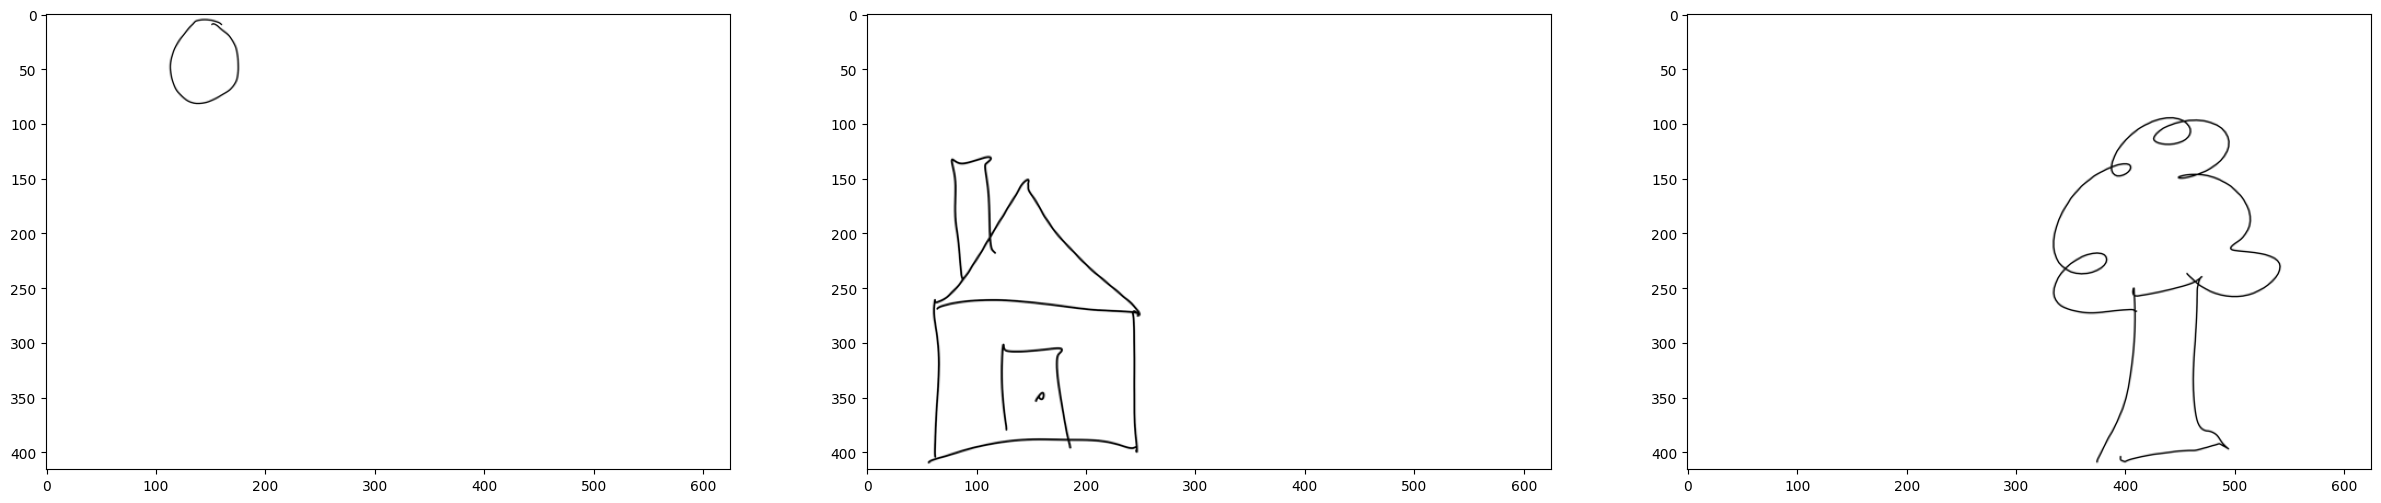

In [29]:
sun_b = sun_vec/la.norm(sun_vec)
house_b = house_vec/la.norm(house_vec)
tree_b = tree_vec/la.norm(tree_vec)

# Now we have an orthonormal basis.

print(f"sun_b is orthogonal to house_b, because their dot product is {sun_b@house_b}.")
print(f"sun_b is orthogonal to tree_b, because their dot product is {sun_b@tree_b}.")
print(f"house_b is orthogonal to tree_b, because their dot product is {house_b@tree_b}.")

print(f"The length of sun_b is {la.norm(sun_b):0.1f}.")
print(f"The length of house_b is {la.norm(house_b):0.1f}.")
print(f"The length of tree_b is {la.norm(tree_b):0.1f}.")


fig,ax=plt.subplots(ncols=3,figsize=[30.,10.])

ax[0].imshow(sun_b.reshape(sun.shape),cmap='binary')
ax[1].imshow(house_b.reshape(sun.shape),cmap='binary')
ax[2].imshow(tree_b.reshape(sun.shape),cmap='binary')


Now we can easily compute the orthonormal approximation to an image using these vectors.

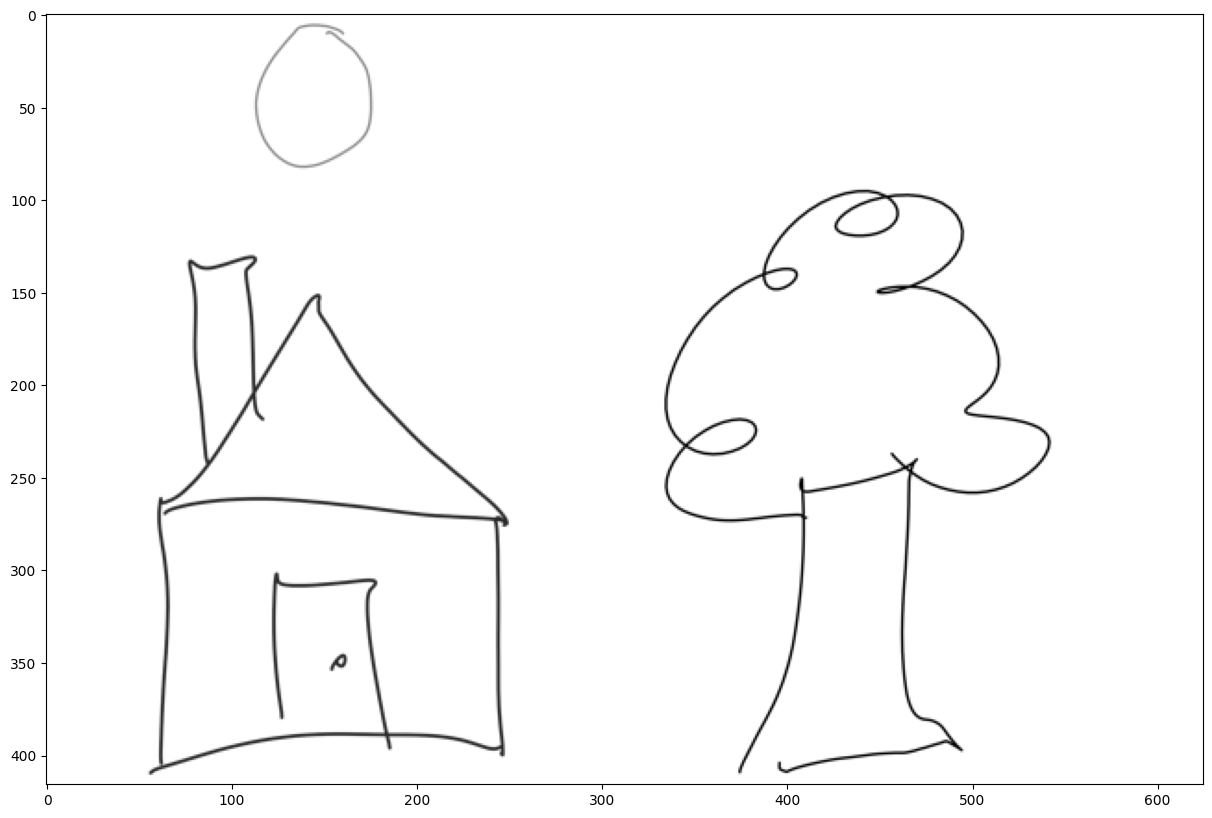

In [30]:
intens = rng.random(3)

random_image = intens[0] * sun + intens[1] * tree + intens[2] * house

fig,ax=plt.subplots(ncols=1,figsize=[20.,10.])

ax.imshow(random_image,cmap='binary')



Let's approximate this image using just the orthonormal vectors `sun_b` and `house_b`.

In [31]:
# H has sun_b and house_b as its columns.

H = np.array([sun_b,house_b]).T

# Check again that they are  orthonormal

print(H.T @ H)

# This code also checks whether H.T@H is the identity matrix. It returns "True" if it is; "False" otherwise.

print
print(np.allclose(H.T @ H, np.identity(2)))

[[1. 0.]
 [0. 1.]]
True


Now project our random image onto the span of `sun_b` and `house_b`

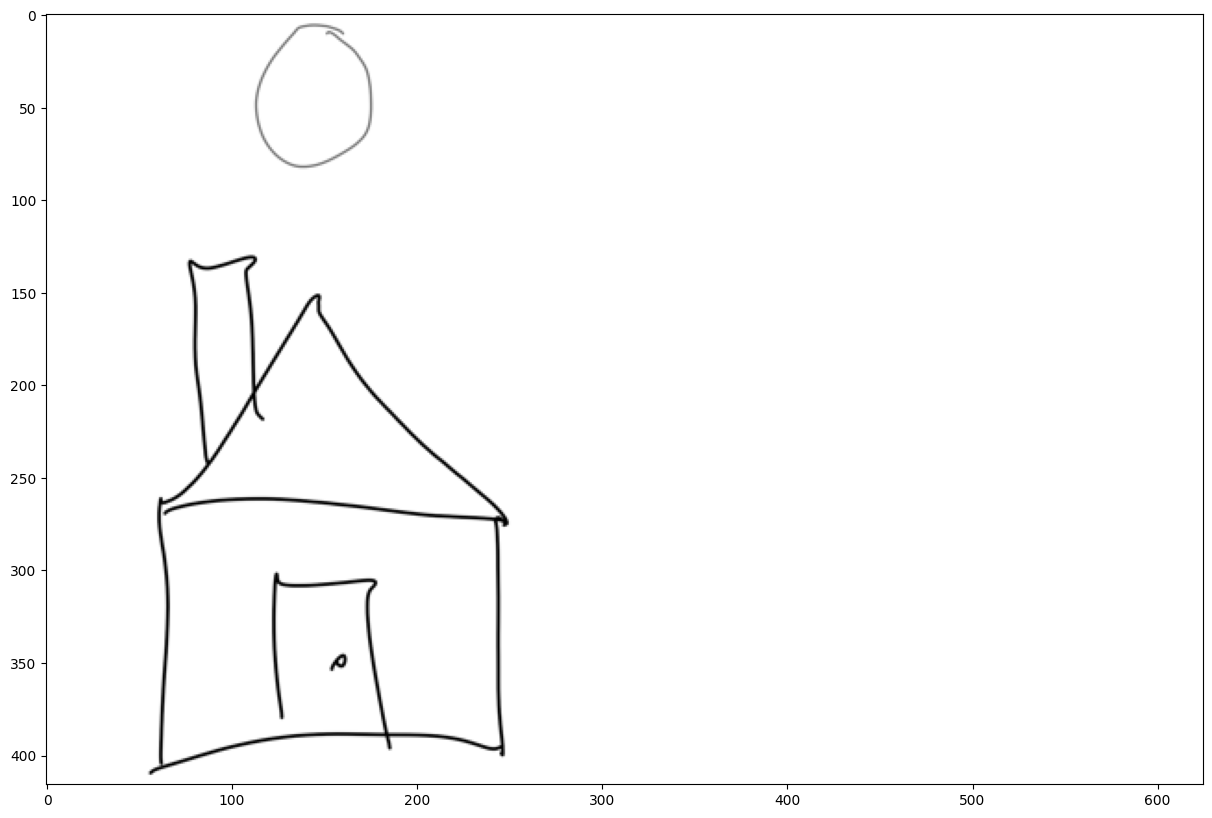

In [32]:
random_image_vec = random_image.reshape(-1)

approximate_image_vec = (random_image_vec @ sun_b) * sun_b + (random_image_vec @ house_b) * house_b

# To display the image, we need to turn the vector into an array of the same shape as the rest of our images.

approximate_image = approximate_image_vec.reshape(sun.shape)

fig,ax=plt.subplots(ncols=1,figsize=[20.,10.])

ax.imshow(approximate_image,cmap='binary')

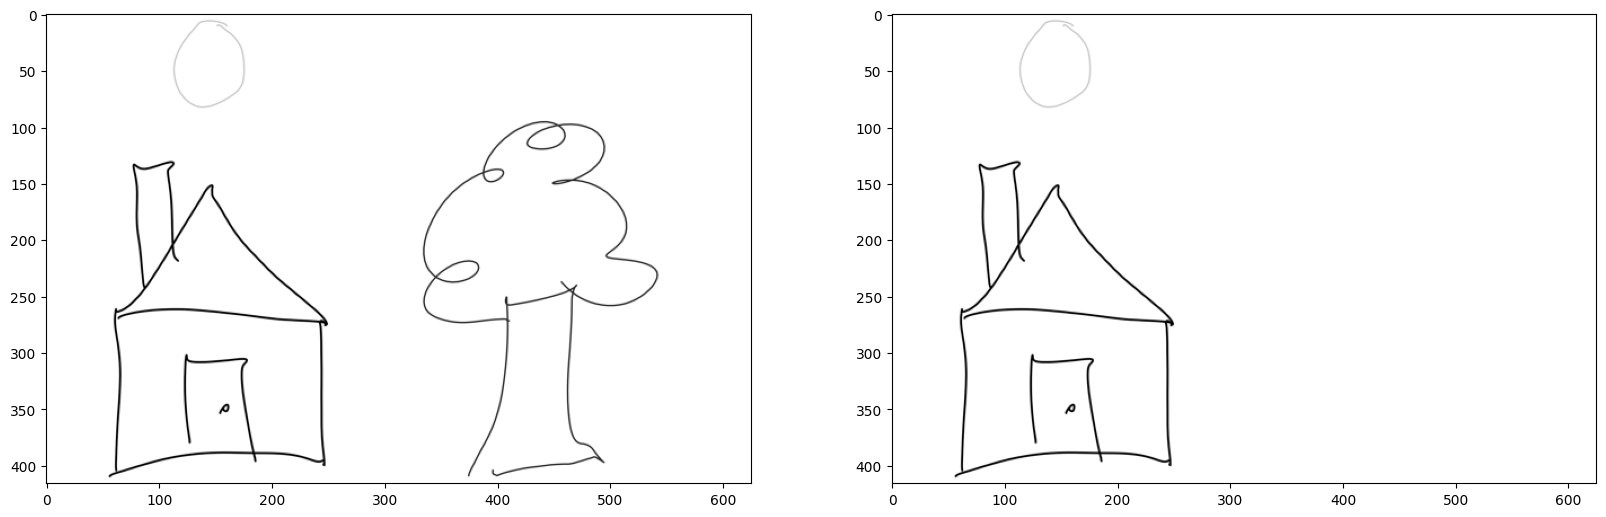

In [33]:
# Maybe it's more convincing to see these together.

# create a random linear combination of sun, house and tree

intens = rng.random(3)
random_image = intens[0] * sun + intens[1] * tree + intens[2] * house

# convert the random image to a vector andapproximate it using orthogonal projection
# onto the span of sun_b and house_b

random_image_vec = random_image.reshape(-1)
approximate_image_vec = (random_image_vec @ sun_b) * sun_b + (random_image_vec @ house_b) * house_b

# Convert appoximate_image_vec to an array of the same shape as our images,
#  and display randomg_mage and approximate_image

approximate_image = approximate_image_vec.reshape(sun.shape)

fig,ax=plt.subplots(ncols=2,figsize=[20.,10.])

ax[0].imshow(random_image,cmap='binary')
ax[1].imshow(approximate_image,cmap='binary')


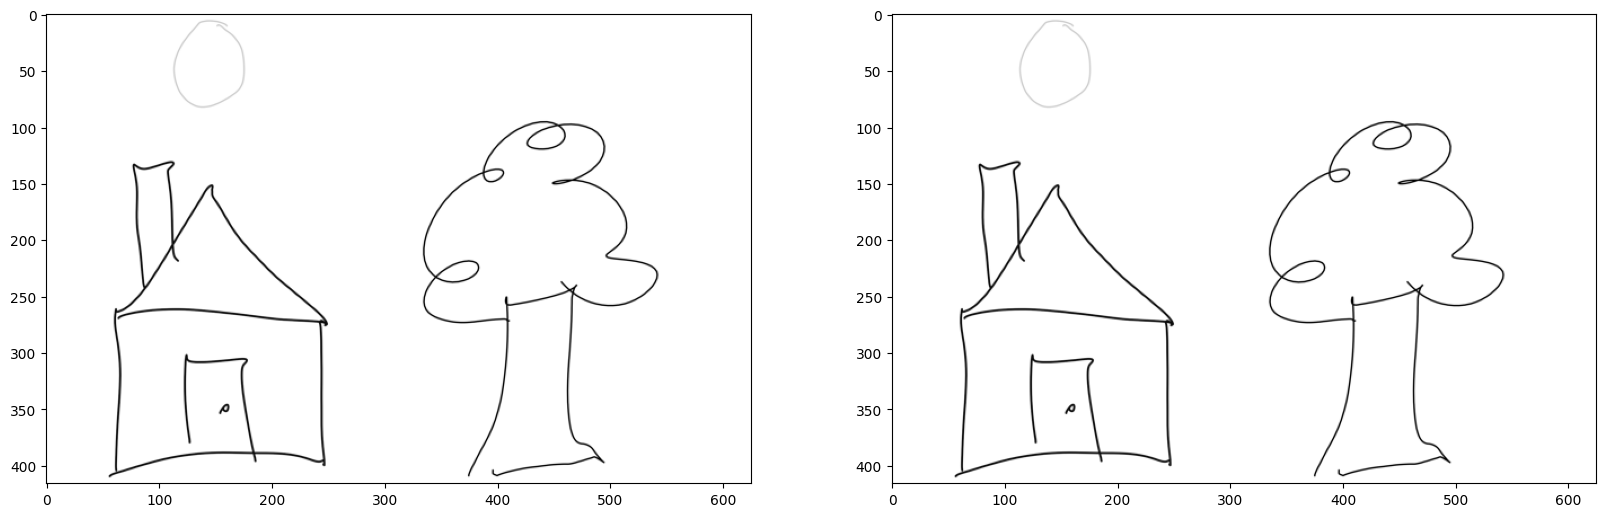

In [34]:
# If you use all three orthonormal vectors you can recover the original image. 

# create a random linear combination of sun, house and tree

intens = rng.random(3)
random_image = intens[0] * sun + intens[1] * tree + intens[2] * house

# convert the random image to a vector and approximate it using orthogonal projection
# onto the span of sun_b, house_b, and tree_b

random_image_vec = random_image.reshape(-1)
approximate_image_vec = (random_image_vec @ sun_b) * sun_b + \
    (random_image_vec @ house_b) * house_b + \
    (random_image_vec @ tree_b)* tree_b

# Convert appoximate_image_vec to an array of the same shape as our images,
#  and display randomg_mage and approximate_image

approximate_image = approximate_image_vec.reshape(sun.shape)

fig,ax=plt.subplots(ncols=2,figsize=[20.,10.])

ax[0].imshow(random_image,cmap='binary')
ax[1].imshow(approximate_image,cmap='binary')


#### **Do It:**

Make a new image `my_image`  as a linear combination `sun`, `house`, and `tree`. Then use the dot product formula with the two orthonormal vectors `house_b` and `tree_b` to find the vector that best approximates your image, using only a linear combination of `house_b` and `tree_b`: that is, compute the orthogonal projection of `my_image` onto the span of those two vectors. Call the approximation `my_approx_vec`.

Reshape `my_approx_vec` into a rectangular array of the same shape as `sun`, called `my_approx`, and then display `my_image`and `my_approx` next to each other as images.

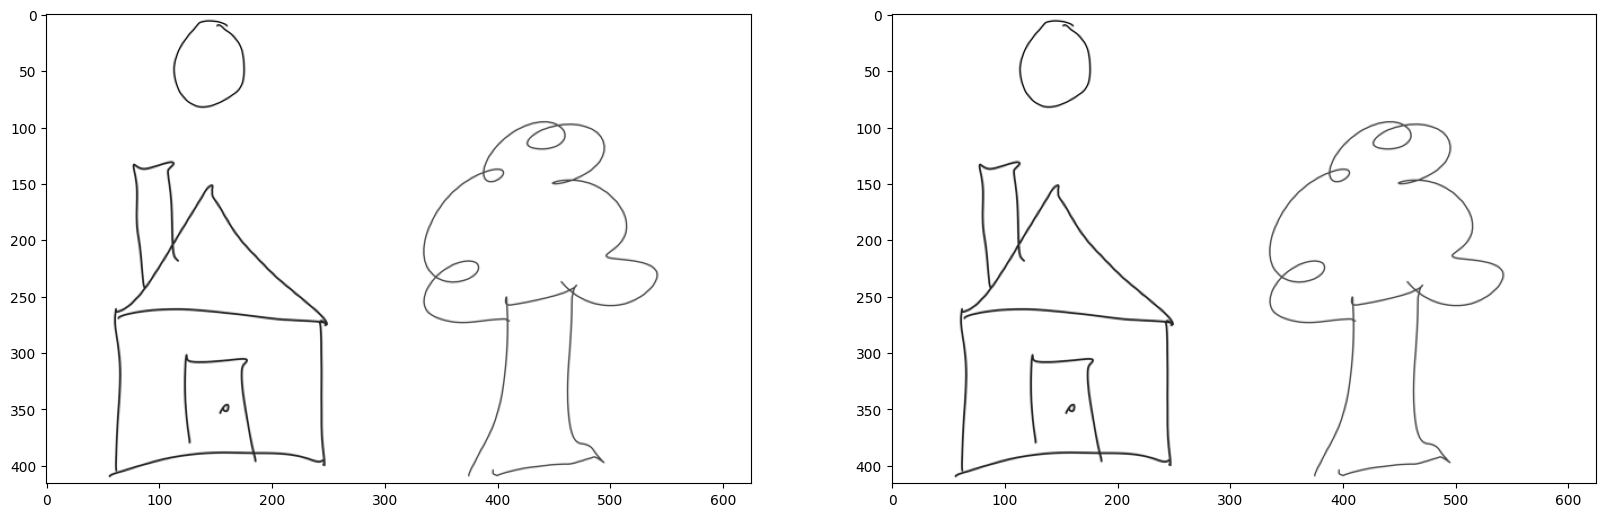

In [35]:
# put your answer in this code cell
my_image = .7 * sun + .5 * tree + .6 * house

# convert the random image to a vector and approximate it using orthogonal projection
# onto the span of sun_b, house_b, and tree_b

my_vec = my_image.reshape(-1)
approximate_image_vec = (my_vec @ sun_b) * sun_b + (my_vec @ house_b) * house_b + (my_vec @ tree_b)* tree_b

# Convert appoximate_image_vec to an array of the same shape as our images,
#  and display randomg_mage and approximate_image

approximate_image = approximate_image_vec.reshape(sun.shape)

fig,ax=plt.subplots(ncols=2,figsize=[20.,10.])

ax[0].imshow(my_image,cmap='binary')
ax[1].imshow(approximate_image,cmap='binary')


Leave this cell for the grader